In [1]:
# Libraries and packages
!pip install geopandas shapely pyproj rtree

import os
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from pandas.tseries.offsets import MonthBegin

In [2]:
### Grid generation and data loading
# Load encampment data
encampments = pd.read_csv('/content/drive/MyDrive/AI4Good 2026/encampments.csv')

# Create GeoDataFrame and project to UTM 17N - meters
encampments_gdf = gpd.GeoDataFrame(
    encampments,
    geometry=gpd.points_from_xy(encampments['lon'], encampments['lat']),
    crs="EPSG:4326"
).to_crs(epsg=32617)

# Generate 100-meter cells over the bounding space
xmin, ymin, xmax, ymax = encampments_gdf.total_bounds
grid_size = 100

cols = np.arange(xmin, xmax + grid_size, grid_size)
rows = np.arange(ymin, ymax + grid_size, grid_size)

polys = []
for x in cols:
    for y in rows:
        polys.append(box(x, y, x + grid_size, y + grid_size))

grid = gpd.GeoDataFrame({'geometry': polys}, crs=encampments_gdf.crs).reset_index().rename(columns={'index': 'cell_id'})

# Spatial Join - Link point instances into respective polygons
joined = gpd.sjoin(encampments_gdf, grid, how="left", predicate="within")
labels = joined.groupby(['cell_id', 'start_timestamp']).size().reset_index(name='count')
labels['presence'] = (labels['count'] > 0).astype(int)

# Form cell x month matrices
all_months = labels['start_timestamp'].unique()
all_cells = grid['cell_id'].unique()

full_index = pd.MultiIndex.from_product([all_cells, all_months], names=['cell_id', 'start_timestamp'])
full_df = pd.DataFrame(index=full_index).reset_index()
full_df['start_timestamp'] = pd.to_datetime(full_df['start_timestamp'], format='%b-%y')
labels['start_timestamp'] = pd.to_datetime(labels['start_timestamp'], format='%b-%y')

# Merge into dataset
full_df = full_df.merge(labels[['cell_id', 'start_timestamp', 'presence']], on=['cell_id', 'start_timestamp'], how='left')
full_df['presence'] = full_df['presence'].fillna(0).astype(int)

# Extract temporal fields
full_df['month'] = full_df['start_timestamp'].dt.month
full_df['year'] = full_df['start_timestamp'].dt.year

# Process centroids for native WGS84 coordinate
grid['centroid'] = grid.geometry.centroid
grid_centroids = grid[['cell_id', 'centroid']].copy().set_geometry('centroid').to_crs(epsg=4326)
grid_centroids['lat'] = grid_centroids.geometry.y
grid_centroids['lon'] = grid_centroids.geometry.x

# Merge into dataset
full_df = full_df.merge(grid_centroids[['cell_id', 'lat', 'lon']], on='cell_id', how='left')

# Sort by temporal features
full_df = full_df.sort_values(['cell_id', 'start_timestamp'])
full_df['lag1'] = full_df.groupby('cell_id')['presence'].shift(1)
full_df['lag2'] = full_df.groupby('cell_id')['presence'].shift(2)
full_df[['lag1', 'lag2']] = full_df[['lag1', 'lag2']].fillna(0)

In [3]:
### Calculate proximity to amenities
def load_service(file):
    df = pd.read_csv(file)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['lon'], df['lat']),
        crs="EPSG:4326"
    ).to_crs(grid.crs)
    return gdf

# Compute nearest Euclidean distance
libraries = load_service('/content/drive/MyDrive/AI4Good 2026/Copy of okai_libraries.csv')
foodbanks = load_service('/content/drive/MyDrive/AI4Good 2026/okai_foodbanks.csv')
comm_rec = load_service('/content/drive/MyDrive/AI4Good 2026/okai_comm_recs_parks.csv')
washrooms = load_service('/content/drive/MyDrive/AI4Good 2026/washrooms.csv')
medical = load_service('/content/drive/MyDrive/AI4Good 2026/medical.csv')
stops = load_service('/content/drive/MyDrive/AI4Good 2026/transit-stops.csv')


def compute_nearest_distance(grid_gdf, service_gdf, feature_name):
    grid_gdf[feature_name] = grid_gdf.geometry.centroid.apply(
        lambda point: service_gdf.distance(point).min()
    )

compute_nearest_distance(grid, libraries, 'dist_library')
compute_nearest_distance(grid, foodbanks, 'dist_foodbank')
compute_nearest_distance(grid, comm_rec, 'dist_comm_rec')
compute_nearest_distance(grid, washrooms, 'dist_washroom')
compute_nearest_distance(grid, medical, 'dist_medical')
compute_nearest_distance(grid, stops, 'dist_stop')

# Merge into dataset
distance_cols = ['dist_library', 'dist_foodbank', 'dist_comm_rec', 'dist_washroom', 'dist_medical', 'dist_stop']
full_df = full_df.merge(grid[['cell_id'] + distance_cols], on='cell_id', how='left')

# Centroids & Neigbours
centroids_meters = grid_centroids.to_crs(epsg=32617).copy()
buffered_cells = centroids_meters.copy()
buffered_cells['geometry'] = buffered_cells.geometry.buffer(500)
buffered_cells = buffered_cells.set_geometry('geometry')

neighbor_join = gpd.sjoin(
    centroids_meters,
    buffered_cells[['cell_id', 'geometry']],
    how='inner',
    predicate='within'
)
neighbor_join = neighbor_join[neighbor_join['cell_id_left'] != neighbor_join['cell_id_right']]
neighbor_dict = neighbor_join.groupby('cell_id_left')['cell_id_right'].apply(list).to_dict()

Running Hyperparameter Optimization via RandomizedSearchCV...
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}

Optimizing Classification Threshold on Real-World (Imbalanced) Splits...
Optimal Threshold Selected: 0.94 (Avg Validation F1: 0.1470)

--- FINAL OPTIMIZED TEST REPORT (2023-2024) ---
ROC-AUC Score: 0.9359
--------------------------------------------------
                   precision    recall  f1-score   support

    No Encampment       1.00      1.00      1.00   1172572
Active Encampment       0.10      0.63      0.17       468

         accuracy                           1.00   1173040
        macro avg       0.55      0.82      0.58   1173040
     weighted avg       1.00      1.00      1.00   1173040



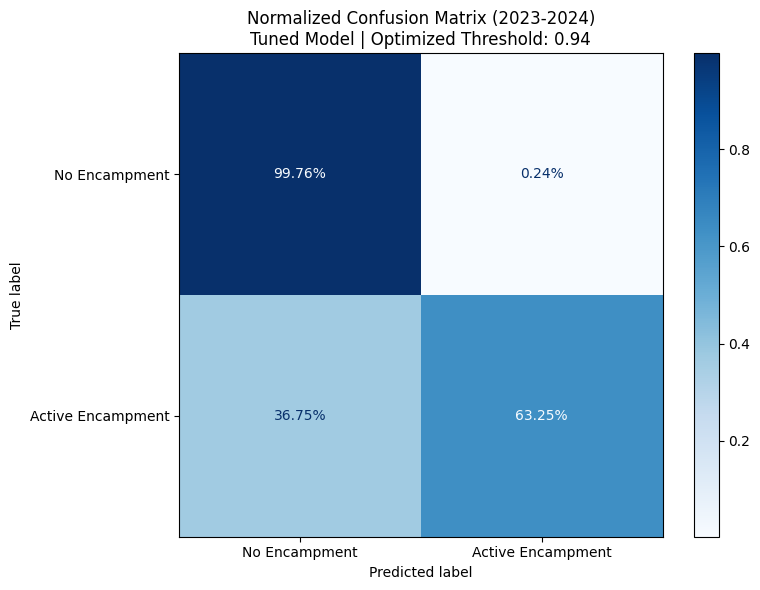

In [5]:
# Parameter tuning and selecting threshold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

full_df['start_timestamp'] = pd.to_datetime(full_df['start_timestamp'])
full_df['year'] = full_df['start_timestamp'].dt.year

feature_cols = ['dist_library', 'dist_foodbank', 'dist_comm_rec', 'dist_washroom', 'dist_medical', 'dist_stop']

# 2021-2022 used for parameter tuning and threshold selection
cv_mask = (full_df['year'] >= 2021) & (full_df['year'] <= 2022)
test_mask = (full_df['year'] >= 2023) & (full_df['year'] <= 2024)

cv_df_raw = full_df[cv_mask].copy()
test_df = full_df[test_mask].copy()

# Raw imbalanced data for target validation extraction
X_cv_raw = cv_df_raw[feature_cols]
y_cv_raw = cv_df_raw['presence']
groups_cv_raw = cv_df_raw['year'].values  # Grouping by year to prevent time leakage

X_test, y_test = test_df[feature_cols], test_df['presence']

# Balance dataset for training
pos_cv = cv_df_raw[cv_df_raw['presence'] == 1]
neg_cv = cv_df_raw[cv_df_raw['presence'] == 0].sample(n=len(pos_cv), random_state=42)
balanced_cv_df = pd.concat([pos_cv, neg_cv]).sample(frac=1, random_state=42)

X_cv_balanced = balanced_cv_df[feature_cols]
y_cv_balanced = balanced_cv_df['presence']
groups_cv_balanced = balanced_cv_df['year'].values

# Optimized hyperparameters
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [4, 10, 20],  # Increased to prevent leaf overfitting on minority class
    'max_features': ['sqrt', 'log2']
}

base_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
gkf_search = GroupKFold(n_splits=2)

# Using average_precision (PR-AUC) instead of standard roc_auc to target the rare class
random_search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='average_precision', # focus on minor class
    cv=gkf_search,
    random_state=42,
    n_jobs=-1
)

print("Hyperparameter optimization via RandomizedSearchCV")
random_search.fit(X_cv_balanced, y_cv_balanced, groups=groups_cv_balanced)
best_hparams = random_search.best_params_
print(f"Best Parameters Found: {best_hparams}\n")

# Chronological threshold search
thresholds = np.linspace(0.05, 0.95, 91)
threshold_f1_scores = {t: [] for t in thresholds}

print("Optimizing classification threshold on imbalanced splits")
gkf_threshold = GroupKFold(n_splits=2)

for fold, (train_idx, val_idx) in enumerate(gkf_threshold.split(X_cv_raw, y_cv_raw, groups=groups_cv_raw)):

    # Isolate imbalanced validation slices
    X_va_raw, y_va_raw = X_cv_raw.iloc[val_idx], y_cv_raw.iloc[val_idx]

    # Extract training slice and balance it inside the loop to preserve fold boundaries
    X_tr_raw, y_tr_raw = X_cv_raw.iloc[train_idx], y_cv_raw.iloc[train_idx]

    pos_idx = y_tr_raw[y_tr_raw == 1].index
    neg_idx = y_tr_raw[y_tr_raw == 0].sample(n=len(pos_idx), random_state=42).index
    balanced_idx = pos_idx.union(neg_idx)

    X_tr_fold = X_tr_raw.loc[balanced_idx]
    y_tr_fold = y_tr_raw.loc[balanced_idx]

    # Fit clone using best pipeline architecture
    fold_clf = RandomForestClassifier(**best_hparams, random_state=42, class_weight='balanced')
    fold_clf.fit(X_tr_fold, y_tr_fold)

    # Generate probability maps against the IMBLANCED validation spectrum
    val_probs = fold_clf.predict_proba(X_va_raw)[:, 1]

    for t in thresholds:
        pred_labels = (val_probs >= t).astype(int)
        # F1 calculation will accurately capture precision penalties here
        score = f1_score(y_va_raw, pred_labels, pos_label=1, zero_division=0)
        threshold_f1_scores[t].append(score)

# Select threshold that survives class imbalance
best_threshold = 0.5
best_avg_f1 = 0.0
for t, scores in threshold_f1_scores.items():
    avg_f1 = np.mean(scores)
    if avg_f1 > best_avg_f1:
        best_avg_f1 = avg_f1
        best_threshold = t

print(f"Optimal Threshold Selected: {best_threshold:.2f} (Avg Validation F1: {best_avg_f1:.4f})\n")

# Testing/Evaluation

# Refit optimal blueprint on complete balanced historical development pool
clf_final = RandomForestClassifier(**best_hparams, random_state=42, class_weight='balanced')
clf_final.fit(X_cv_balanced, y_cv_balanced)

y_test_probs = clf_final.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Optimised Testing")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_probs):.4f}")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=["No Encampment", "Active Encampment"]))

# Confusion Matrix
cm_normalized = confusion_matrix(y_test, y_test_pred, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["No Encampment", "Active Encampment"])
disp.plot(cmap='Blues', ax=ax, values_format='.2%')

plt.title(f"Normalized Confusion Matrix \nTuned Model | Optimized Threshold: {best_threshold:.2f}")
plt.tight_layout()
plt.show()

In [6]:
# Model with tuned params
clf = RandomForestClassifier(n_estimators = 300,
                             min_samples_split = 10,
                             min_samples_leaf = 4,
                             max_features = 'sqrt',
                             max_depth = 15
    )

clf.fit(X_cv_balanced, y_cv_balanced)

### build empty calendar for future months
last_month = full_df['start_timestamp'].max()
future_months = pd.date_range(start=last_month + MonthBegin(1), periods=12, freq='MS')

future_index = pd.MultiIndex.from_product([all_cells, future_months], names=['cell_id', 'start_timestamp'])
future_df = pd.DataFrame(index=future_index).reset_index()

# Merge into dataset
full_future_df = pd.concat([full_df, future_df], ignore_index=True)
full_future_df = full_future_df.sort_values(['cell_id', 'start_timestamp']).reset_index(drop=True)
full_future_df['presence'] = full_future_df['presence'].fillna(0).astype(float)

# Backfill features to empty future months columns
static_features = full_df.drop_duplicates('cell_id')[['cell_id', 'lat', 'lon'] + distance_cols].set_index('cell_id')
for col in ['lat', 'lon'] + distance_cols:
    full_future_df[col] = full_future_df['col_placeholder'] = full_future_df['cell_id'].map(static_features[col])
full_future_df = full_future_df.drop(columns=['col_placeholder'])

# compute lags for each month
print("Starting recursive execution loop")
for current_time in future_months:
    print(f"Projecting Spatial Densities")

    full_future_df['lag1'] = full_future_df.groupby('cell_id')['presence'].shift(1)
    full_future_df['lag2'] = full_future_df.groupby('cell_id')['presence'].shift(2)
    full_future_df[['lag1', 'lag2']] = full_future_df[['lag1', 'lag2']].fillna(0)

    full_future_df['month'] = full_future_df['start_timestamp'].dt.month
    full_future_df['year'] = full_future_df['start_timestamp'].dt.year

    time_mask = full_future_df['start_timestamp'] == current_time
    current_lag1 = full_future_df[time_mask].set_index('cell_id')['lag1']

    # Calculate continuous dynamic spatial lag transformations
    spatial_lags = []
    for cell in full_future_df.loc[time_mask, 'cell_id']:
        neighbors = neighbor_dict.get(cell, [])
        valid_neighbors = [n for n in neighbors if n in current_lag1.index]
        s_lag = current_lag1.loc[valid_neighbors].sum() if valid_neighbors else 0
        spatial_lags.append(s_lag)

    full_future_df.loc[time_mask, 'spatial_lag_1mo'] = spatial_lags

    # Extract clean feature matrix for processing
    X_step = full_future_df.loc[time_mask, feature_cols]

    if not X_step.empty:
        # feed predicted probability back into presence column
        y_step_proba = clf.predict_proba(X_step)[:, 1]
        full_future_df.loc[time_mask, 'pred_proba'] = y_step_proba
        full_future_df.loc[time_mask, 'presence'] = y_step_proba
        full_future_df.loc[time_mask, 'pred_class'] = (y_step_proba > 0.5).astype(int)

print("\nDone")

Starting recursive execution loop
Projecting Spatial Densities: 2024-09
Projecting Spatial Densities: 2024-10
Projecting Spatial Densities: 2024-11
Projecting Spatial Densities: 2024-12
Projecting Spatial Densities: 2025-01
Projecting Spatial Densities: 2025-02
Projecting Spatial Densities: 2025-03
Projecting Spatial Densities: 2025-04
Projecting Spatial Densities: 2025-05
Projecting Spatial Densities: 2025-06
Projecting Spatial Densities: 2025-07
Projecting Spatial Densities: 2025-08

Done


In [27]:
## Map Visualisation
import pandas as pd
import folium
from folium.plugins import HeatMap
from IPython.display import display, HTML

# Isolate the final forecasted month
final_month = full_future_df['start_timestamp'].max()
final_preds = full_future_df[full_future_df['start_timestamp'] == final_month].copy()

# Merge predictions with your grid
map_df = grid.merge(final_preds, on='cell_id')

# Filter for high-risk areas based on your best_threshold
high_risk_threshold = best_threshold
growth_df = map_df[map_df['pred_proba'] >= high_risk_threshold].copy()

# Initialize the base map
center_lat = growth_df['lat'].mean()
center_lon = growth_df['lon'].mean()

interactive_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11.5,
    tiles='CartoDB positron'
)

# Generate data points
heat_data = growth_df[['lat', 'lon', 'pred_proba']].values.tolist()
HeatMap(
    heat_data,
    name='High-Risk Encampment Growth Areas',
    min_opacity=0.3,
    radius=14,    # Laser width
    blur=10,      # Laser softness
    gradient={0.4: '#fcbba1', 0.7: '#fb6a4a', 1.0: '#cb181d'}
).add_to(interactive_map)

for _, row in growth_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=12,
        color='none',
        fill=True,
        fill_color='none',
        fill_opacity=0,
        tooltip=(
            f"<b>Cell ID:</b> {int(row['cell_id'])}<br>"
            f"<b>Probability:</b> {row['pred_proba']:.3f}<br>"
            f"<b>Class:</b> {int(row['pred_class'])}"
        )
    ).add_to(interactive_map)

mid_point = high_risk_threshold + ((1.0 - high_risk_threshold) / 2)

map_html = interactive_map._repr_html_()

# Build the side legend HTML
legend_html = f"""
<div style="
    width: 150px;
    background-color: white;
    padding: 20px;
    font-family: Arial, Helvetica, sans-serif;
    border-left: 1px solid #e0e0e0;
    display: flex;
    flex-direction: column;
    justify-content: center; /* This centers the contents vertically */
    height: 100%;            /* Ensure it fills the height to allow vertical centering */
    ">
    <h4 style="margin-top:0; margin-bottom: 20px; font-size: 14px; color: #333; text-align: center;">

        <span style="font-size:12px;color:#777;"></span>
    </h4>
    <div style="display: flex; height: 250px; justify-content: center;">
        <div style="
            width: 24px;
            height: 100%;
            background: linear-gradient(to top, #fcbba1 0%, #fb6a4a 50%, #cb181d 100%);
            border: 1px solid #ccc;
            border-radius: 4px;
        "></div>

        <div style="
            display: flex;
            flex-direction: column;
            justify-content: space-between;
            font-size: 13px;
            color: #222;
            font-weight: 500;
            margin-top: -8px;
            margin-bottom: -8px;
        ">
            <div style="display: flex; align-items: center;">
                <div style="width: 8px; height: 2px; background-color: #888; margin-right: 6px;"></div>
                <span>1.000</span>
            </div>
            <div style="display: flex; align-items: center;">
                <div style="width: 8px; height: 2px; background-color: #888; margin-right: 6px;"></div>
                <span>{mid_point:.3f}</span>
            </div>
            <div style="display: flex; align-items: center;">
                <div style="width: 8px; height: 2px; background-color: #888; margin-right: 6px;"></div>
                <span>{high_risk_threshold:.3f}</span>
            </div>
        </div>
    </div>
</div>
"""

# Wrap both inside a flexbox container
container_html = f"""
<div style="
    display: flex;
    flex-direction: row;
    border: 1px solid #e0e0e0;
    border-radius: 8px;
    overflow: hidden;
    background: white;
    height: 600px; /* Set a fixed height so vertical centering is obvious */
    ">
    <div style="flex-grow: 1; min-width: 0;">
        {map_html}
    </div>
    <div style="display: flex; align-items: center;">
        {legend_html}
    </div>
</div>
"""

display(HTML(container_html))

/tmp/ipykernel_1918/519774337.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




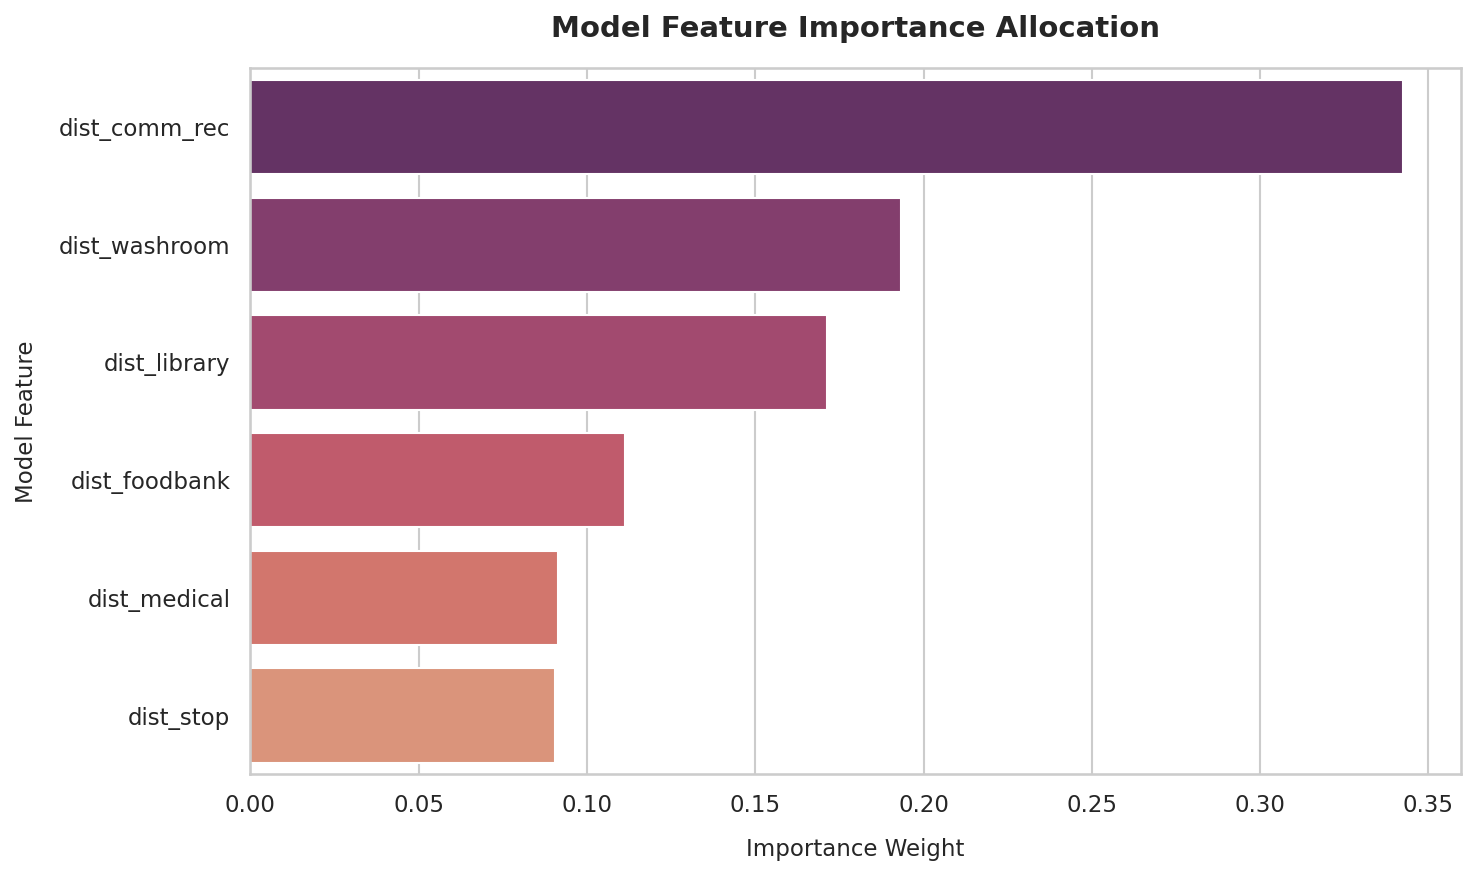


Values
Model Feature Dimension  Relative Importance Weight
          dist_comm_rec                    0.342532
          dist_washroom                    0.193309
           dist_library                    0.171250
          dist_foodbank                    0.111190
           dist_medical                    0.091292
              dist_stop                    0.090427


In [28]:
### Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importances = clf.feature_importances_

# Build DataFrame for plotting
importance_df = pd.DataFrame({
    'Model Feature Dimension': feature_cols,
    'Relative Importance Weight': importances
})

# Sort features by importance weight
importance_df = importance_df.sort_values(by='Relative Importance Weight', ascending=False)

# Initialize the matplotlib canvas
plt.figure(figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid")

# Plot bar plot
ax = sns.barplot(
    x='Relative Importance Weight',
    y='Model Feature Dimension',
    data=importance_df,
    palette='flare_r'
)

plt.title('Model Feature Importance Allocation', fontsize=14, pad=15, fontweight='semibold')
plt.xlabel('Importance Weight', fontsize=11, labelpad=10)
plt.ylabel('Model Feature', fontsize=11, labelpad=10)
plt.tight_layout()

# Display the final distribution
plt.show()
print("\nValues")
print(importance_df.to_string(index=False))